### MNIST classifier using Cyclic projections
This notebook shows an implementation of the algorithm from scratch, benchmarking the effect of the number of backward passes and the effect of initialization

In [5]:
%load_ext autoreload
%autoreload 2
import matplotlib
matplotlib.use('Agg')

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.append(os.path.abspath(os.getcwd()))

import jax.numpy as jnp
import jax.random as random
import tools.projections as projections
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import optax

from torchvision.datasets import MNIST
from torch.utils.data import DataLoader

rand_key = random.key(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
### Setup problem
NUM_CLASSES   = 10
HIDDEN_WIDTH  = 128
IN_FEATURES   = 784
BATCH_SIZE    = 64
BACKWARDS_PASSES = 10
NUM_EPOCHS    = 1
DELTA         = 1.0
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081

def load_mnist(batch_size=64, data_dir="./dataset"):
    def collate_fn(batch):
        images, labels = zip(*batch)
        x = np.array(images, dtype=np.float32) / 255.0
        y = np.array(labels, dtype=np.int64)
        if x.ndim == 3: x = x[..., None]
        x = (x - MNIST_MEAN) / MNIST_STD
        return x, y
    train_ds = MNIST(data_dir, train=True, download=True)
    test_ds  = MNIST(data_dir, train=False, download=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, drop_last=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, drop_last=False)
    return train_loader, test_loader

def prepare_batch(x_np, y_np):
    batch = x_np.shape[0]
    x_in = jnp.array(x_np.reshape(batch, -1).T, dtype=jnp.float32)
    y_target = jax.nn.one_hot(jnp.array(y_np), NUM_CLASSES).T
    return x_in, y_target

def forward_pass(W0, W1, x_in, y_target):
    x_hidden = W0 @ x_in
    h_hidden = jnp.where(x_hidden > 0, x_hidden, 0.1 * x_hidden)
    x_out    = W1 @ h_hidden
    err_pos = jnp.where(y_target == 1, jnp.where(x_out < DELTA, (x_out - DELTA)**2, 0.0), 0.0)
    err_neg = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0.0), 0.0)
    return err_pos + err_neg, x_hidden, h_hidden, x_out

def compute_accuracy(W0, W1, loader, max_batches=None):
    correct, total = 0, 0
    for i, (x_np, y_np) in enumerate(loader):
        if max_batches is not None and i >= max_batches: break
        x_in, y_target = prepare_batch(x_np, y_np)
        _, _, _, x_out = forward_pass(W0, W1, x_in, y_target)
        correct += int(jnp.sum(jnp.argmax(x_out, axis=0) == jnp.array(y_np)))
        total += len(y_np)
    return correct / total if total > 0 else 0.0

train_loader, test_loader = load_mnist(BATCH_SIZE)

## Cyclic projections

In [43]:
### Run Cyclic Projections Experiment (batched MNIST) - Varying Backward Passes
backward_passes_list = [1, 5, 10, 20]
all_results = []

# 1. Generate initial weights once so each run starts from the exact same initialization
key = rand_key
key, k1, k2 = random.split(key, 3)
initial_W0 = random.normal(k1, (HIDDEN_WIDTH, IN_FEATURES)) * 0.01
initial_W1 = random.normal(k2, (NUM_CLASSES, HIDDEN_WIDTH)) * 0.01

for bps in backward_passes_list:
    print(f"\n--- Running with BACKWARDS_PASSES = {bps} ---")
    
    # Reset weights to the shared initialization
    W0 = initial_W0
    W1 = initial_W1
    
    global_step = 0
    test_iter = iter(test_loader)
    for epoch in range(NUM_EPOCHS):
        epoch_errors = []
        for batch_idx, (x_np, y_np) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} (BP={bps})")):
            x_in, y_target = prepare_batch(x_np, y_np)
            batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, x_in, y_target)

            # Loop using the current experimental value for backward passes
            for bp in range(bps):
                x_out, _, _ = projections.classifierOutput(x_out, jnp.eye(NUM_CLASSES), y_target)
                h_hidden, W1, x_out = projections.matMul(h_hidden, W1, x_out)
                x_hidden, _, h_hidden = projections.leakyRelu(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
                x_in, W0, x_hidden = projections.matMulfixedX(x_in, W0, x_hidden)

            batchError, _, _, x_out_log = forward_pass(W0, W1, x_in, y_target)
            current_error = float(jnp.mean(batchError))
            train_acc = float(jnp.mean(jnp.argmax(x_out_log, axis=0) == jnp.array(y_np)))

            test_acc = compute_accuracy(W0, W1, test_loader)
            epoch_errors.append(current_error)
            
            # Store results with the BP parameter
            all_results.append({
                "BackwardPasses": bps, 
                "Epoch": epoch, 
                "Step": global_step, 
                "Error": current_error, 
                "TrainAcc": train_acc, 
                "ValAcc": test_acc
            })
            global_step += 1

        test_acc = compute_accuracy(W0, W1, test_loader)
        print(f"  Epoch {epoch+1} — Avg Error: {np.mean(epoch_errors):.4e}  Val Acc: {test_acc:.4f}")
        
    final_acc = compute_accuracy(W0, W1, test_loader)
    print(f"Final Test Accuracy (BP={bps}): {final_acc:.4f}")



--- Running with BACKWARDS_PASSES = 1 ---


Epoch 1/1 (BP=1): 100%|██████████| 937/937 [04:17<00:00,  3.65it/s]


  Epoch 1 — Avg Error: 3.0190e-02  Val Acc: 0.9001
Final Test Accuracy (BP=1): 0.9001

--- Running with BACKWARDS_PASSES = 5 ---


Epoch 1/1 (BP=5): 100%|██████████| 937/937 [04:16<00:00,  3.65it/s]


  Epoch 1 — Avg Error: 1.8523e-02  Val Acc: 0.9283
Final Test Accuracy (BP=5): 0.9283

--- Running with BACKWARDS_PASSES = 10 ---


Epoch 1/1 (BP=10): 100%|██████████| 937/937 [04:29<00:00,  3.48it/s]


  Epoch 1 — Avg Error: 1.4005e-02  Val Acc: 0.9394
Final Test Accuracy (BP=10): 0.9394

--- Running with BACKWARDS_PASSES = 20 ---


Epoch 1/1 (BP=20): 100%|██████████| 937/937 [04:36<00:00,  3.39it/s]


  Epoch 1 — Avg Error: 9.3426e-03  Val Acc: 0.9467
Final Test Accuracy (BP=20): 0.9467


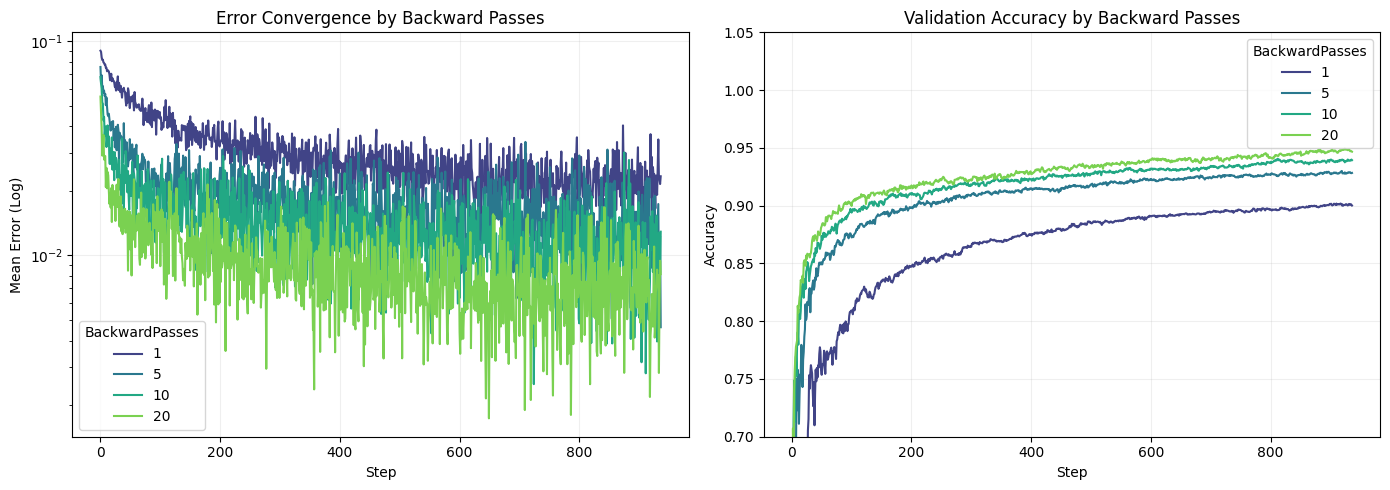

In [44]:
%matplotlib inline

# 2. Visualize and report the performance differences
df_all = pd.DataFrame(all_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Error
sns.lineplot(data=df_all, x="Step", y="Error", hue="BackwardPasses", palette=sns.color_palette("viridis", 4), ax=ax1)
ax1.set_yscale('log')
ax1.set_title("Error Convergence by Backward Passes")
ax1.set_ylabel("Mean Error (Log)")
ax1.grid(True, alpha=0.2)

# Plot Validation Accuracy
sns.lineplot(data=df_all, x="Step", y="ValAcc", hue="BackwardPasses", palette=sns.color_palette("viridis", 4), ax=ax2)
ax2.set_ylim(0.7, 1.05)
ax2.set_title("Validation Accuracy by Backward Passes")
ax2.set_ylabel("Accuracy")
ax2.grid(True, alpha=0.2)

fig.tight_layout()
plt.savefig('mnist_cyclic_pure_bp_comparison.pdf', dpi=300)
plt.show()

# The Effect of Initialization

In [16]:
import jax.numpy as jnp
import jax.random as random

def _semi_orthogonal(key, shape):
    """Semi-orthogonal via QR. For (m, n) with m <= n, rows are orthonormal."""
    rows, cols = shape
    n = max(rows, cols)
    A = random.normal(key, (n, n))
    Q, R = jnp.linalg.qr(A)
    Q = Q * jnp.sign(jnp.diag(R))[None, :]   # Haar-uniform sign fix
    return Q[:rows, :cols]

def init_status_quo(key):
    """Original notebook init: std = 0.01 (much smaller than He/Xavier)."""
    k0, k1 = random.split(key, 2)
    W0 = random.normal(k0, (HIDDEN_WIDTH, IN_FEATURES)) * 0.01
    W1 = random.normal(k1, (NUM_CLASSES,  HIDDEN_WIDTH)) * 0.01
    return W0, W1

def init_he(key):
    """He normal: var = 2/fan_in. The standard PyTorch default for ReLU."""
    k0, k1 = random.split(key, 2)
    W0 = random.normal(k0, (HIDDEN_WIDTH, IN_FEATURES)) * jnp.sqrt(2.0 / IN_FEATURES)
    W1 = random.normal(k1, (NUM_CLASSES,  HIDDEN_WIDTH)) * jnp.sqrt(2.0 / HIDDEN_WIDTH)
    return W0, W1

def init_xavier(key):
    """Glorot normal: var = 1/fan_in."""
    k0, k1 = random.split(key, 2)
    W0 = random.normal(k0, (HIDDEN_WIDTH, IN_FEATURES)) * jnp.sqrt(1.0 / IN_FEATURES)
    W1 = random.normal(k1, (NUM_CLASSES,  HIDDEN_WIDTH)) * jnp.sqrt(1.0 / HIDDEN_WIDTH)
    return W0, W1

def init_orthogonal_he(key):
    """Semi-orthogonal × √2. All singular values equal to √2 (ReLU gain).
    The argument from the response: minimizes contraction factor in vanishing-target theorem."""
    k0, k1 = random.split(key, 2)
    W0 = _semi_orthogonal(k0, (HIDDEN_WIDTH, IN_FEATURES)) * jnp.sqrt(2.0)
    W1 = _semi_orthogonal(k1, (NUM_CLASSES,  HIDDEN_WIDTH)) * jnp.sqrt(2.0)
    return W0, W1


INIT_STRATEGIES = {
    "status_quo (std=0.01)": init_status_quo,
    "He normal":             init_he,
    "Xavier normal":         init_xavier,
    "Orthogonal × √2":       init_orthogonal_he,
}

In [31]:
DEPTH        = 4        # try 4 first, then 8
HIDDEN_DEEP  = 128      # smaller width to keep compute tractable
BACKWARDS_PASSES = 50

def init_he_deep(key, widths):
    keys = random.split(key, len(widths) - 1)
    return [random.normal(k, (widths[i+1], widths[i])) * jnp.sqrt(2.0 / widths[i])
            for i, k in enumerate(keys)]

def init_orth_deep(key, widths):
    keys = random.split(key, len(widths) - 1)
    return [_semi_orthogonal(k, (widths[i+1], widths[i])) * jnp.sqrt(2.0)
            for i, k in enumerate(keys)]

def init_status_quo_deep(key, widths):
    keys = random.split(key, len(widths) - 1)
    return [random.normal(k, (widths[i+1], widths[i])) * 0.01
            for i, k in enumerate(keys)]

INIT_DEEP = {
    "normal distribution (std=0.01)": init_status_quo_deep,
    "He normal":             init_he_deep,
    "Orthogonal × √2":       init_orth_deep,
}

def forward_deep(Ws, x_in, y_target):
    pre_acts, post_acts = [], []
    h = x_in
    for W in Ws[:-1]:
        z = W @ h
        pre_acts.append(z)
        h = jnp.where(z > 0, z, 0.1 * z)
        post_acts.append(h)
    x_out = Ws[-1] @ h
    err_pos = jnp.where(y_target == 1, jnp.where(x_out < DELTA, (x_out - DELTA)**2, 0.0), 0.0)
    err_neg = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0.0), 0.0)
    return err_pos + err_neg, pre_acts, post_acts, x_out

def cyclic_step_deep(Ws, pre_acts, post_acts, x_in, x_out, y_target, eye_hidden):
    L = len(Ws)
    x_out, _, _ = projections.classifierOutput(x_out, jnp.eye(NUM_CLASSES), y_target)
    post_acts[-1], Ws[-1], x_out = projections.matMul(post_acts[-1], Ws[-1], x_out)
    for i in range(L - 2, -1, -1):
        pre_acts[i], _, post_acts[i] = projections.leakyRelu(pre_acts[i], eye_hidden, post_acts[i])
        if i == 0:
            x_in, Ws[0], pre_acts[0] = projections.matMulfixedX(x_in, Ws[0], pre_acts[0])
        else:
            post_acts[i-1], Ws[i], pre_acts[i] = projections.matMul(post_acts[i-1], Ws[i], pre_acts[i])
    return Ws, pre_acts, post_acts, x_in, x_out

def run_deep(init_fn, label, depth=DEPTH, hidden=HIDDEN_DEEP,
             num_epochs=2, batches_per_epoch=200, key=None):
    if key is None: key = rand_key
    widths = [IN_FEATURES] + [hidden] * (depth - 1) + [NUM_CLASSES]
    Ws = init_fn(key, widths)
    eye_hidden = jnp.eye(hidden)

    train_loader, test_loader = load_mnist(BATCH_SIZE)
    results, global_step = [], 0
    test_iter = iter(test_loader)
    for epoch in range(num_epochs):
        epoch_errors = []
        for batch_idx, (x_np, y_np) in enumerate(tqdm(train_loader, desc=f"[{label} L={depth}] Ep {epoch+1}")):
            if batches_per_epoch is not None and batch_idx >= batches_per_epoch: break
            x_in, y_target = prepare_batch(x_np, y_np)
            _, pre_acts, post_acts, x_out = forward_deep(Ws, x_in, y_target)
            for bp in range(BACKWARDS_PASSES):
                Ws, pre_acts, post_acts, x_in, x_out = cyclic_step_deep(
                    Ws, pre_acts, post_acts, x_in, x_out, y_target, eye_hidden)
            err, _, _, x_out_log = forward_deep(Ws, x_in, y_target)
            current_error = float(jnp.mean(err))
            train_acc = float(jnp.mean(jnp.argmax(x_out_log, axis=0) == jnp.array(y_np)))
            try: x_val_np, y_val_np = next(test_iter)
            except StopIteration:
                test_iter = iter(test_loader); x_val_np, y_val_np = next(test_iter)
            x_val_in, y_val_target = prepare_batch(x_val_np, y_val_np)
            _, _, _, x_val_out = forward_deep(Ws, x_val_in, y_val_target)
            val_acc = float(jnp.mean(jnp.argmax(x_val_out, axis=0) == jnp.array(y_val_np)))
            epoch_errors.append(current_error)
            results.append({"Init": label, "Depth": depth, "Epoch": epoch, "Step": global_step,
                            "Error": current_error, "TrainAcc": train_acc, "ValAcc": val_acc})
            global_step += 1
        if epoch_errors:
            print(f"  [{label} L={depth}] Epoch {epoch+1} — Avg Err: {np.mean(epoch_errors):.4e}")
    return pd.DataFrame(results)

[normal distribution (std=0.01) L=2] Ep 1:  21%|██▏       | 200/937 [00:05<00:18, 39.77it/s]


  [normal distribution (std=0.01) L=2] Epoch 1 — Avg Err: 6.2989e-03


[He normal L=2] Ep 1:  21%|██▏       | 200/937 [00:04<00:18, 40.49it/s]


  [He normal L=2] Epoch 1 — Avg Err: 2.3779e-02


[Orthogonal × √2 L=2] Ep 1:  21%|██▏       | 200/937 [00:04<00:18, 40.37it/s]


...

  [normal distribution (std=0.01) L=8] Epoch 1 — Avg Err: 1.0000e-01


[He normal L=8] Ep 1:  21%|██▏       | 200/937 [00:16<00:59, 12.33it/s]


  [He normal L=8] Epoch 1 — Avg Err: 6.3901e-02


[Orthogonal × √2 L=8] Ep 1:  21%|██▏       | 200/937 [00:16<00:59, 12.32it/s]
/tmp/ipykernel_2088731/2520854106.py:8: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  g = sns.relplot(data=df_deep, x="Step", y="ValAcc", hue="Init", col="Depth", kind="line",


  [Orthogonal × √2 L=8] Epoch 1 — Avg Err: 5.2088e-02


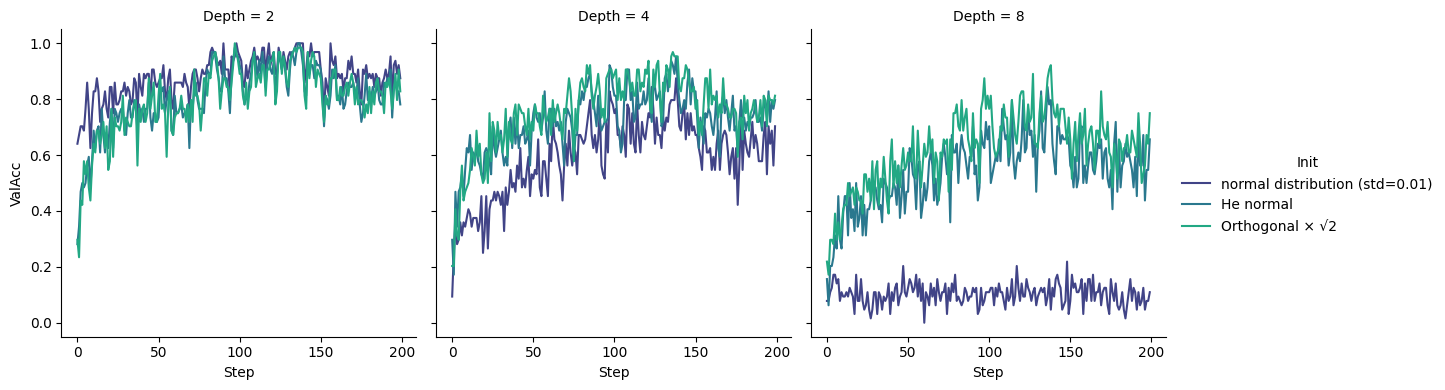

<Figure size 640x480 with 0 Axes>

In [ ]:
deep_dfs = []
for depth in [2, 4, 8]:
    for label, init_fn in INIT_DEEP.items():
        df = run_deep(init_fn, label, depth=depth, num_epochs=1, batches_per_epoch=200)
        deep_dfs.append(df)
df_deep = pd.concat(deep_dfs, ignore_index=True)

/tmp/ipykernel_2088731/1226603220.py:1: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  g = sns.relplot(data=df_deep, x="Step", y="ValAcc", hue="Init", col="Depth", kind="line",


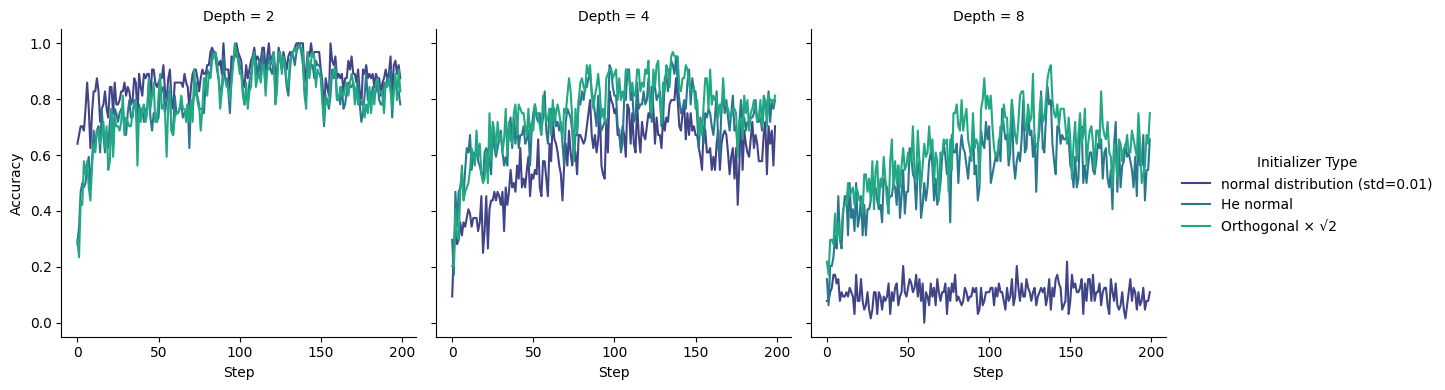

In [42]:
g = sns.relplot(data=df_deep, x="Step", y="ValAcc", hue="Init", col="Depth", kind="line",
                col_wrap=3, height=4, facet_kws={"sharey": True}, palette=sns.color_palette("viridis", 4))
g.set_titles("Depth = {col_name}")
g.set_axis_labels("Step", "Accuracy")
g._legend.set_title("Initializer Type")
plt.savefig("effect_of_init.pdf", dpi=300, bbox_inches="tight")
plt.show()
